In [6]:
# !python -m pip install pandas
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df=pd.read_excel(r"C:\Users\fahad\Downloads\Superstore_Analysis_Project\EDA process\Superstore_Sales_Analysis_Project.xlsx",sheet_name="Orders")

In [8]:
# df.head(10)
df.info()
# df["Sales"].sum()
# df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Row ID                     10194 non-null  int64         
 1   Order ID                   10194 non-null  str           
 2   Order Date                 10194 non-null  datetime64[us]
 3   Ship Date                  10194 non-null  datetime64[us]
 4   Ship Mode                  10194 non-null  str           
 5   Customer ID                10194 non-null  str           
 6   Customer Name              10194 non-null  str           
 7   Segment                    10194 non-null  str           
 8   Country                    10194 non-null  str           
 9   City                       10194 non-null  str           
 10  State                      10194 non-null  str           
 11  Postal Code                10194 non-null  object        
 12  Region         

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,First Order Line (Helper),Returned Flag (Helper)
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417,0.501373,0.078478
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.000000,0.000000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800,0.000000,0.000000
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000,1.000000,0.000000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925,1.000000,0.000000
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,1.000000,1.000000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115,0.500023,0.268935


In [10]:
df.isnull().sum()
# df.nunique()
# df.dtypes

Row ID                       0
Order ID                     0
Order Date                   0
Ship Date                    0
Ship Mode                    0
Customer ID                  0
Customer Name                0
Segment                      0
Country                      0
City                         0
State                        0
Postal Code                  0
Region                       0
Product ID                   0
Category                     0
Sub-Category                 0
Product Name                 0
Sales                        0
Quantity                     0
Discount                     0
Profit                       0
First Order Line (Helper)    0
Returned Flag (Helper)       0
dtype: int64

In [11]:
#Change the data type of Order_Date and Ship_Date to datetime
# df["Order_Date"]=pd.to_datetime(df["Order_Date"],dayfirst=True)
# df["Ship_Date"]=pd.to_datetime(df["Ship_Date"],dayfirst=True)

In [12]:
# # df.columns
# df=df.drop(columns=["Unnamed: 20"])

In [13]:
#In order to avoid any issues with column names, we can strip any leading or trailing whitespace and
#  replace spaces with underscores. This will make it easier to reference columns in the future.
df.columns=df.columns.str.strip()
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)


In [14]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'First_Order_Line_(Helper)', 'Returned_Flag_(Helper)'],
      dtype='str')

In [15]:
#In this step, we are renaming the columns to make them more readable and easier to work with.
#  We are replacing spaces with underscores and removing any special characters.
df=df.rename(columns={
    "Sub-Category": "Sub_Category",
    "First_Order_Line_(Helper)":"First_Order_Line",
    "Returned_Flag_(Helper)":"Returned_Flag"
})

In [16]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'First_Order_Line', 'Returned_Flag'],
      dtype='str')

In [17]:
# df["Sales"].head()
# df["Profit"].head()
# df["Discount"].head()
df.head(10)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,First_Order_Line,Returned_Flag
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,1,0
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,1,0
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,0,0
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,0,0
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,1,0
5,6,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078,1,0
6,7,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,OFF-AR-10001662,Office Supplies,Art,Rogers Handheld Barrel Pencil Sharpener,5.480,2,0.0,1.4796,0,0
7,8,US-2023-106054,2023-01-06,2023-01-07,First Class,JO-15145,Jack O'Briant,Corporate,United States,Athens,...,OFF-AR-10002399,Office Supplies,Art,"Dixon Prang Watercolor Pencils, 10-Color Set w...",12.780,3,0.0,5.2398,1,0
8,9,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,609.980,2,0.0,274.4910,0,0
9,10,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,OFF-FA-10001883,Office Supplies,Fasteners,"Alliance Super-Size Bands, Assorted Sizes",31.120,4,0.0,0.3112,0,0


In [18]:
#IN this step, we are cleaning the Sales, Profit, and Discount columns by removing any special characters and converting them to numeric data types.
#  This will allow us to perform calculations and analysis on these columns more easily.
df["Sales"]=(df["Sales"]
 .astype(str).str.replace("$","",regex=False)
 .str.replace(",","",regex=False)
 .str.strip()
)

df["Profit"]=(df["Profit"]
 .astype(str).str.replace("$","",regex=False)
 .str.replace(",","",regex=False)
 .str.strip()
)

df["Discount"]=(df["Discount"]
 .astype(str)
 .str.replace("%","",regex=False)
 .str.strip()
)

In [19]:
#In this step, we are converting the Sales, Profit, and Discount columns to numeric data types.
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")

In [20]:
#this step, we are checking for any missing values in the Profit column. If there are any missing values,
#  we will need to decide how to handle them before proceeding with our analysis.
df[df["Profit"].isnull()]

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,First_Order_Line,Returned_Flag


In [21]:
total_sales=df["Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,326,534.35


In [22]:
total_profit=df["Profit"].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $292,296.81


In [23]:
total_quantity=df["Quantity"].sum()
print(f"Total Quantity: {total_quantity:,}")

Total Quantity: 38,654


In [24]:
total_orders=df["Order_ID"].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 5,111


In [25]:
total_customers=df["Customer_ID"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 804


In [26]:
profit_margin_pct= (total_profit / total_sales) * 100
print(f"Profit Margin: {profit_margin_pct:.2f}%")

Profit Margin: 12.56%


In [27]:
#this step, we are creating a new DataFrame called kpi that contains 
# the key performance indicators (KPIs) for our analysis.
kpi=pd.DataFrame({
    "Metric":[
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Total Orders",
        "Total Customers",
        "Profit Margin%" 
    ],
    "Values":[
        total_sales,
        total_profit,
        total_quantity,
        total_orders,
        total_customers,
        profit_margin_pct
    ]
})
# Format the values column to display as normal numbers with 2 decimal places
kpi["Values"] = kpi["Values"].map("{:,.2f}".format)
print(kpi)

            Metric        Values
0      Total Sales  2,326,534.35
1     Total Profit    292,296.81
2   Total Quantity     38,654.00
3     Total Orders      5,111.00
4  Total Customers        804.00
5   Profit Margin%         12.56


In [28]:
#Category Analysis
category_analysis=(
    df.groupby("Category")
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum")
    )
    .reset_index()
 )

category_analysis["Profit_Margin"]=(
    category_analysis["Profit"] / 
    category_analysis["Sales"] * 100
)

category_analysis= category_analysis.sort_values(
    by="Sales",ascending=False
)

print(category_analysis)

          Category        Sales       Profit  Quantity  Profit_Margin
2       Technology  839893.2790  146543.3756      7017      17.447857
0        Furniture  754747.7613   19729.9956      8369       2.614118
1  Office Supplies  731893.3140  126023.4434     23268      17.218827


In [29]:
#Region Analysis
region_analysis=(
    df.groupby("Region")
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum")
    )
    .reset_index()
 )

region_analysis["Profit_Margin"]=(
    region_analysis["Profit"] / 
    region_analysis["Sales"] * 100
)

region_analysis= region_analysis.sort_values(
    by="Sales",ascending=False
)

print(region_analysis)

    Region        Sales       Profit  Quantity  Profit_Margin
3     West  739813.6085  110798.8170     12466      14.976585
1     East  691828.1680   94883.2603     11159      13.714859
0  Central  503170.6728   39865.3070      8820       7.922820
2    South  391721.9050   46749.4303      6209      11.934342


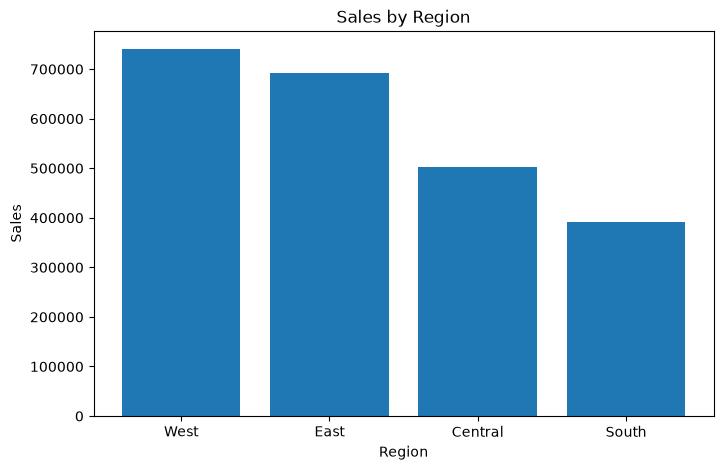

In [30]:
#this step, we are creating a bar chart to visualize the sales by region.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

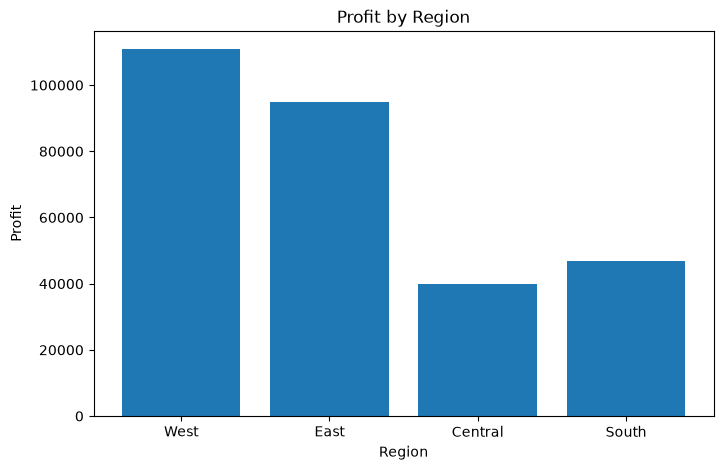

In [31]:
#this step, we are creating a bar chart to visualize the profit by region.
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Profit"]
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [32]:
#Product Analysis
#This step, we are creating a new DataFrame called top_products_sales that contains the top 10 products by sales.
top_products_sales=(
    df.groupby(["Product_ID","Product_Name"])
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum")
    )
    .reset_index()
    .sort_values(by="Sales",ascending=False)
    .head(10)
 )
print(top_products_sales)

           Product_ID                                       Product_Name  \
1640  TEC-CO-10004722              Canon imageCLASS 2200 Advanced Copier   
787   OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Bin...   
1669  TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferenci...   
82    FUR-CH-10002024       HON 5400 Series Task Chairs for Big and Tall   
701   OFF-BI-10001359         GBC DocuBind TL300 Electric Binding System   
667   OFF-BI-10000545   GBC Ibimaster 500 Manual ProClick Binding System   
1630  TEC-CO-10001449               Hewlett Packard LaserJet 3310 Copier   
1657  TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer ...   
858   OFF-BI-10004995          GBC DocuBind P400 Electric Binding System   
1443  OFF-SU-10000151        High Speed Automatic Electric Letter Opener   

          Sales        Profit  Quantity  
1640  61599.824  2.519993e+04        20  
787   27453.384  7.753039e+03        31  
1669  22638.480 -1.811078e+03        

In [33]:
#This step, we are creating a new DataFrame called top_products_profit that contains the top 10 products by profit.
top_products_profit=(
    df.groupby(["Product_ID","Product_Name"])
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum")
    )
    .reset_index()
    .sort_values(by="Profit",ascending=False)
    .head(10)
 )
print(top_products_profit)

           Product_ID                                       Product_Name  \
1640  TEC-CO-10004722              Canon imageCLASS 2200 Advanced Copier   
787   OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Bin...   
1630  TEC-CO-10001449               Hewlett Packard LaserJet 3310 Copier   
1637  TEC-CO-10003763                 Canon PC1060 Personal Laser Copier   
1657  TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer ...   
1693  TEC-MA-10003979                  Ativa V4110MDD Micro-Cut Shredder   
1656  TEC-MA-10001047   3D Systems Cube Printer, 2nd Generation, Magenta   
1541  TEC-AC-10002049  Plantronics Savi W720 Multi-Device Wireless He...   
692   OFF-BI-10001120               Ibico EPK-21 Electric Binding System   
1643  TEC-MA-10000045                  Zebra ZM400 Thermal Label Printer   

          Sales      Profit  Quantity  
1640  61599.824  25199.9280        20  
787   27453.384   7753.0390        31  
1630  18839.686   6983.8836        38  
163

In [71]:
#This step, we are creating a new DataFrame called loss_products that contains the products that have a negative profit.
loss_products=(
    df.groupby(["Product_ID","Product_Name"])
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum")
        
    )
    .reset_index()
    .query("Profit < 0")
    .sort_values("Profit")
 )
print(loss_products.head(10))

           Product_ID                                       Product_Name  \
1645  TEC-MA-10000418          Cubify CubeX 3D Printer Double Head Print   
1650  TEC-MA-10000822          Lexmark MX611dhe Monochrome Laser Printer   
1696  TEC-MA-10004125          Cubify CubeX 3D Printer Triple Head Print   
326   FUR-TA-10000198  Chromcraft Bull-Nose Wood Oval Conference Tabl...   
344   FUR-TA-10001889  Bush Advantage Collection Racetrack Conference...   
858   OFF-BI-10004995          GBC DocuBind P400 Electric Binding System   
1669  TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferenci...   
1465  OFF-SU-10002881  Martin Yale Chadless Opener Electric Letter Op...   
346   FUR-TA-10001950                       Balt Solid Wood Round Tables   
375   FUR-TA-10004289  BoxOffice By Design Rectangular and Half-Moon ...   

          Sales     Profit  
1645  11099.963 -8879.9704  
1650  16829.901 -4589.9730  
1696   7999.980 -3839.9904  
326    9917.640 -2876.1156  
344    9544.725 -1

In [35]:
##Discount vs Profit Analysis
#IN this step, we are creating a new column called Discount_Band that categorizes the discount into different bands.
df["Discount_Band"]=pd.cut(
    df["Discount"],
    bins=[-1,0,20,40,float("inf")],
    labels=["0%","1-20%","21-40%",">40%"]
)

discount_analysis=(
    df.groupby("Discount_Band",observed=False)
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum")
    )
    .reset_index()
)

discount_analysis["Profit_Margin"]=(
    discount_analysis["Profit"] /
    discount_analysis["Sales"] * 100
)

print(discount_analysis)

  Discount_Band         Sales       Profit  Quantity  Profit_Margin
0            0%  1.105324e+06  326718.5872     18770      29.558632
1         1-20%  1.221211e+06  -34421.7726     19884      -2.818660
2        21-40%  0.000000e+00       0.0000         0            NaN
3          >40%  0.000000e+00       0.0000         0            NaN


In [36]:
#Customer Analysis
#This step, we are creating a new DataFrame called customer_analysis that contains the top 10 customers by sales.
customer_analysis=(
    df.groupby(["Customer_ID","Customer_Name"])
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum"),
        Orders=("Order_ID","nunique")
    )
    .reset_index()
    .sort_values(by="Sales",ascending=False)
 )
print(customer_analysis.head(10))

    Customer_ID       Customer_Name      Sales     Profit  Quantity  Orders
711    SM-20320         Sean Miller  25043.050 -1980.7393        50       5
752    TC-20980        Tamara Chand  19052.218  8981.3239        42       5
632    RB-19360        Raymond Buch  15117.339  6976.0959        71       6
741    TA-21385        Tom Ashbrook  14595.620  4703.7883        36       4
6      AB-10105       Adrian Barton  14473.571  5444.8055        73      10
443    KL-16645        Ken Lonsdale  14175.229   806.8550       113      12
680    SC-20095        Sanjit Chand  14142.334  5757.4119        87       9
328    HL-15040        Hunter Lopez  12873.298  5622.4292        50       6
694    SE-20110        Sanjit Engle  12209.438  2650.6769        78      11
132    CC-12370  Christopher Conant  12129.072  2177.0493        34       5


In [37]:
#This step, we are creating a new DataFrame called customer_analysis that contains the top 10 customers by profit.
customer_analysis=(
    df.groupby(["Customer_ID","Customer_Name"])
    .agg(
        Profit=("Profit","sum"),
        Sales=("Sales","sum"),
        Quantity=("Quantity","sum"),
        Orders=("Order_ID","nunique")
    )
    .reset_index()
    .sort_values(by="Profit",ascending=False)
)
print(customer_analysis.head(10))

    Customer_ID         Customer_Name     Profit      Sales  Quantity  Orders
752    TC-20980          Tamara Chand  8981.3239  19052.218        42       5
632    RB-19360          Raymond Buch  6976.0959  15117.339        71       6
680    SC-20095          Sanjit Chand  5757.4119  14142.334        87       9
328    HL-15040          Hunter Lopez  5622.4292  12873.298        50       6
6      AB-10105         Adrian Barton  5444.8055  14473.571        73      10
741    TA-21385          Tom Ashbrook  4703.7883  14595.620        36       4
161    CM-12385  Christopher Martinez  3899.8904   8954.020        34       4
433    KD-16495         Keith Dawkins  3038.6254   8181.256        84      12
48     AR-10540           Andy Reiter  2884.6208   6608.448        33       6
235    DR-12940         Daniel Raglin  2869.0760   8350.868        57       8


In [38]:
#This step, we are analyzing the customers who have placed multiple orders.
customer_Multiple_Orders=(
    df.groupby(["Customer_ID","Customer_Name"])
    .agg(
        Orders=("Order_ID","nunique"),
        Profit=("Profit","sum")
    )
    .reset_index()
    .query("Orders > 1")
    .sort_values(by="Orders",ascending=False)
)
print(customer_Multiple_Orders)

    Customer_ID      Customer_Name  Orders    Profit
276    EP-13915         Emily Phan      17  144.9578
713    SM-20950     Suzanne McNair      14  610.1142
100    BP-11095       Bart Pistole      14  702.9642
262    EH-14125  Eugene Hildebrand      14  117.8102
702    SH-19975      Sally Hughsby      13  558.4740
..          ...                ...     ...       ...
418    JT-12540       Jill Trafton       2 -197.6036
412    JS-13215   Jennifer Sheldon       2    8.9910
409    JR-15670        Jim Radford       2 -785.1645
69     BD-11560     Brendan Dodson       2  116.7140
53     AS-10135       Adrian Shami       2   21.8496

[792 rows x 4 columns]


In [39]:
#This step, we are creating a new DataFrame called customer_negative_profit that contains the customers who have a negative profit.
customer_negative_profit=(
    df.groupby(["Customer_ID","Customer_Name"])
    .agg(
        Profit=("Profit","sum"),
        Sales=("Sales","sum")
    )
    .reset_index()
    .query("Profit < 0")
)
print(
    customer_negative_profit
    .sort_values(by="Profit", ascending=True)
    .head(10)
)

    Customer_ID     Customer_Name     Profit      Sales
181    CS-12505     Cindy Stewart -6626.3895   5690.055
311    GT-14635    Grant Thornton -4108.6589   9351.212
468    LF-17185       Luke Foster -3583.9770   3930.509
722    SR-20425    Sharelle Roach -3333.9144   3233.481
323    HG-14965     Henry Goldwyn -2797.9635   3247.642
565    NC-18415       Nathan Cano -2204.8072   2218.990
677    SB-20290      Sean Braxton -2082.7451   8057.891
711    SM-20320       Sean Miller -1980.7393  25043.050
166    CP-12340    Christine Phan -1850.3029   5888.275
571    NF-18385  Natalie Fritzler -1695.9714   8322.826


In [40]:
print(
    customer_analysis
    .query("Profit < 0")
    .sort_values("Profit")
    .count()
)


Customer_ID      159
Customer_Name    159
Profit           159
Sales            159
Quantity         159
Orders           159
dtype: int64


In [41]:
##Time-Series and Product Analysis
monthly_analysis=(
    df.groupby(df["Order_Date"].dt.to_period("M"))
    .agg(
        Sales=("Sales","sum"),
        Profit=("Profit","sum"),
        Quantity=("Quantity","sum"),
        Orders=("Order_ID","nunique")
    )
    .reset_index()
)
print(monthly_analysis.head(10))

  Order_Date       Sales     Profit  Quantity  Orders
0    2023-01  14518.0550  2539.3907       306      33
1    2023-02   4519.8920   862.3084       159      28
2    2023-03  56933.9090   693.4499       597      72
3    2023-04  28295.3450  3488.8352       536      66
4    2023-05  26319.7670  3196.3918       504      72
5    2023-06  34669.4796  4999.7594       524      67
6    2023-07  33946.3930  -841.4826       550      65
7    2023-08  28918.3385  5765.2250       624      75
8    2023-09  82670.4288  8593.6302      1015     134
9    2023-10  32413.3390  3469.1749       605      81


In [42]:
monthly_analysis["Order_Date"]=(
    monthly_analysis["Order_Date"].dt.to_timestamp()
)

In [43]:
#Top Sales months
print(
    monthly_analysis
    .sort_values("Sales",ascending=False)
    .head(10)
)

   Order_Date        Sales      Profit  Quantity  Orders
46 2026-11-01  118454.5050   9692.1037      1842     262
35 2025-12-01   97502.2770  17926.3013      1476     185
44 2026-09-01   88064.5320  11050.8024      1685     231
47 2026-12-01   85175.0328   8655.8269      1820     236
45 2026-10-01   83474.7832  10670.5312      1166     151
8  2023-09-01   82670.4288   8593.6302      1015     134
34 2025-11-01   79411.9658   4011.4075      1406     183
10 2023-11-01   78826.9567   9362.9557      1235     152
22 2024-11-01   75972.5635  12474.7884      1310     158
23 2024-12-01   75532.5572   8093.0627      1243     167


In [44]:
#Top Profit by Months
print(
    monthly_analysis
    .sort_values("Profit",ascending=False)
    .head(10)
)

   Order_Date        Sales      Profit  Quantity  Orders
35 2025-12-01   97502.2770  17926.3013      1476     185
33 2025-10-01   59831.0010  16256.8422       770     107
38 2026-03-01   60728.4808  15013.0910       914     121
22 2024-11-01   75972.5635  12474.7884      1310     158
44 2026-09-01   88064.5320  11050.8024      1685     231
45 2026-10-01   83474.7832  10670.5312      1166     151
14 2024-03-01   39978.6280   9930.6134       528      81
46 2026-11-01  118454.5050   9692.1037      1842     262
11 2023-12-01   72008.3085   9554.6571      1158     150
43 2026-08-01   64129.7580   9488.0722       899     114


In [45]:
#Loss making Months
print(
    monthly_analysis
    .query("Profit < 0")
    .sort_values("Profit")
)

   Order_Date       Sales     Profit  Quantity  Orders
12 2024-01-01  18461.9156 -3189.8030       260      31
6  2023-07-01  33946.3930  -841.4826       550      65


In [46]:
time_trend = (
    df.groupby(df["Order_Date"].dt.to_period("Y"))[["Sales", "Profit"]]
    .sum()
    .reset_index()
)
print(time_trend)

  Order_Date        Sales      Profit
0       2023  494040.2121  51684.2957
1       2024  472993.0310  62020.9695
2       2025  613933.5800  82665.2018
3       2026  745567.5312  95926.3476


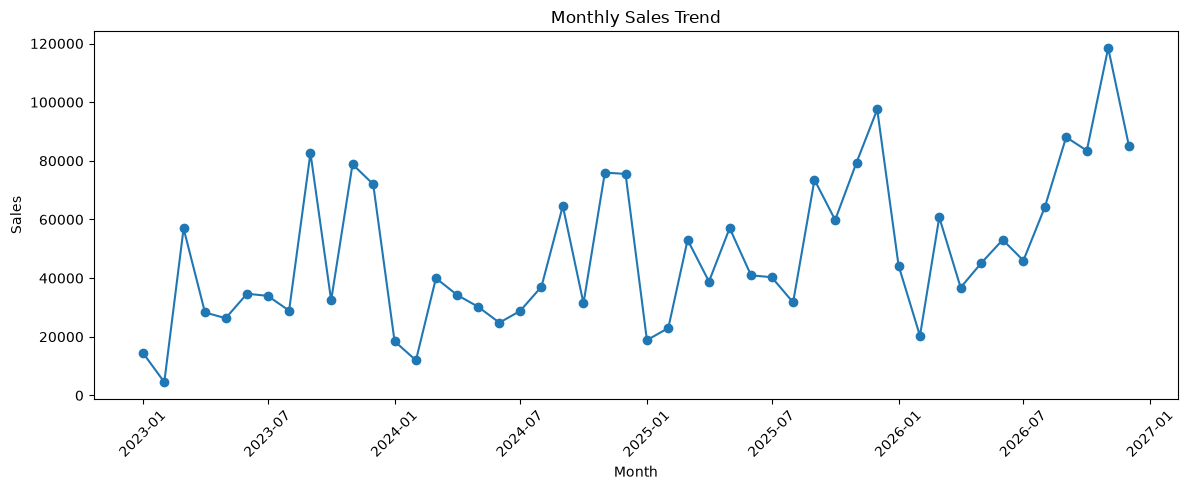

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["Order_Date"],
    monthly_analysis["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

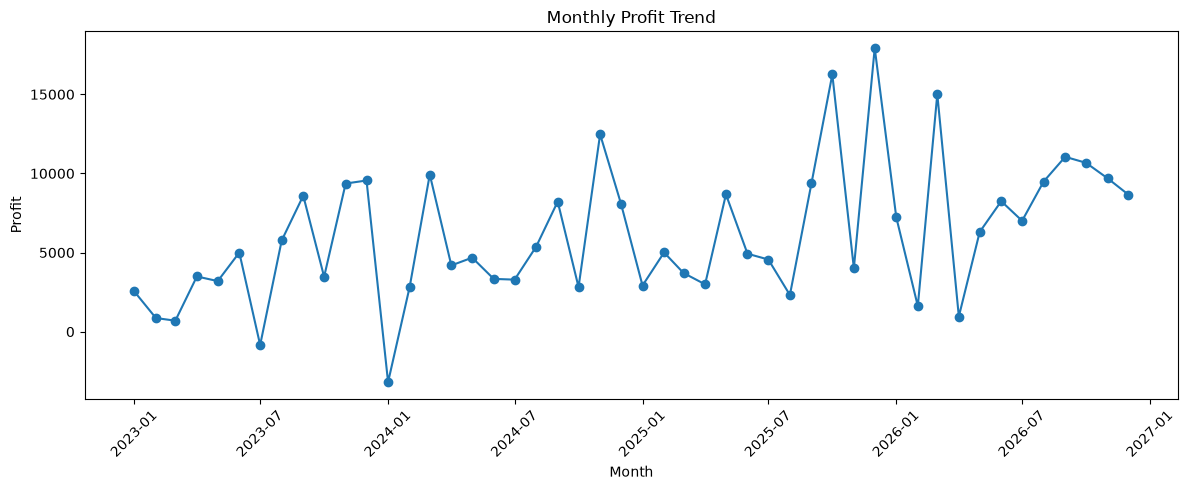

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["Order_Date"],
    monthly_analysis["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

          Category        Sales
0        Furniture  754747.7613
1  Office Supplies  731893.3140
2       Technology  839893.2790


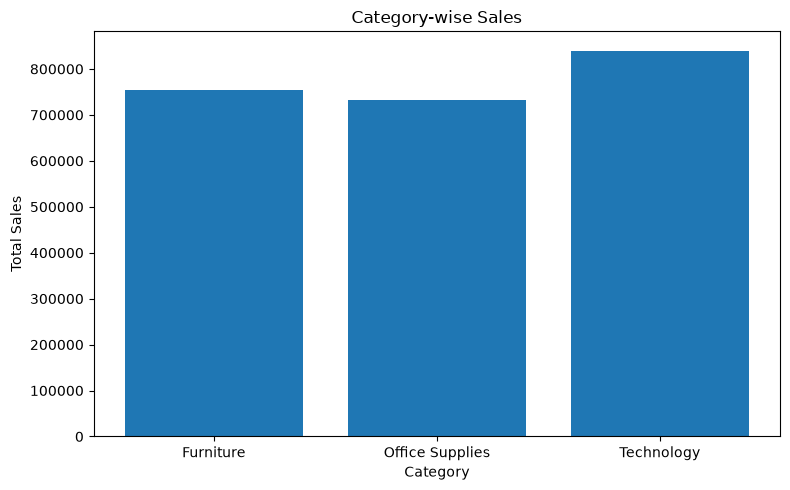

In [49]:
category_analysis = (
    df.groupby("Category")
      .agg(Sales=("Sales", "sum"))
      .reset_index()
)

print(category_analysis)

plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Sales"]
)

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


    Region       Profit
0  Central   39865.3070
1     East   94883.2603
2    South   46749.4303
3     West  110798.8170


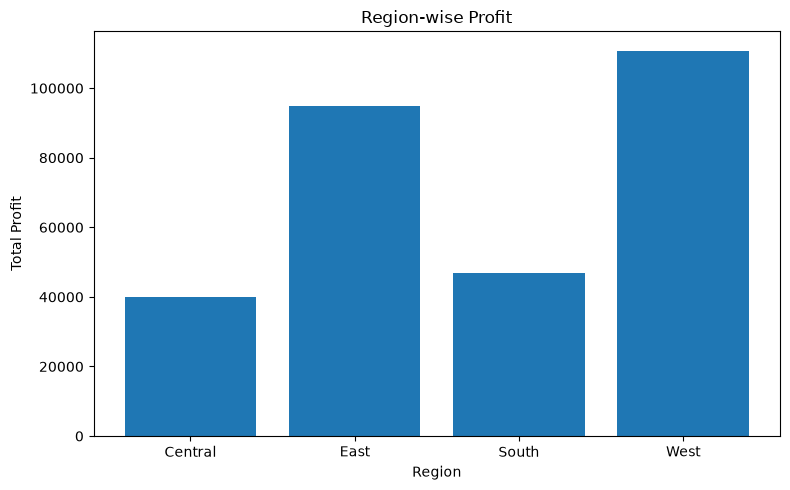

In [50]:
region_analysis = (
    df.groupby("Region")
      .agg(Profit=("Profit", "sum"))
      .reset_index()
)

print(region_analysis)

plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Profit"]
)

plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
##Sub-Category Analysis
subcategory_analysis = (
    df.groupby("Sub_Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .reset_index()
)
subcategory_analysis["Profit_Margin"]=(
    subcategory_analysis["Profit"] /
    subcategory_analysis["Sales"] * 100
)

print(subcategory_analysis)

   Sub_Category        Sales      Profit  Quantity  Orders  Profit_Margin
0   Accessories  167380.3180  41936.6357      2976     718      25.054700
1    Appliances  108213.1850  18329.4844      1750     459      16.938310
2           Art   27659.0140   6653.1962      3092     756      24.054351
3       Binders  207354.8810  31426.1003      6071    1339      15.155708
4     Bookcases  115361.2043  -3632.0736       878     228      -3.148436
5        Chairs  335768.2490  27223.5323      2431     591       8.107834
6       Copiers  150745.2900  56093.9365       242      70      37.211071
7     Envelopes   16528.3620   6988.0247       914     251      42.278991
8     Fasteners    8532.2400   2428.6358       980     226      28.464223
9   Furnishings   95598.1260  13891.7430      3799     919      14.531397
10       Labels   12695.0420   5572.7780      1410     348      43.897279
11     Machines  189925.0310   3461.9769       442     114       1.822812
12        Paper   79540.5380  34511.50

In [52]:
#top 10 sub_catagpries by Sales
print(
    subcategory_analysis
    .sort_values("Sales",ascending=False)
    .head(10)

)


   Sub_Category        Sales      Profit  Quantity  Orders  Profit_Margin
5        Chairs  335768.2490  27223.5323      2431     591       8.107834
13       Phones  331842.6400  45050.8265      3357     826      13.575961
14      Storage  224644.5540  21285.1115      3191     787       9.475018
16       Tables  208020.1820 -17753.2061      1261     314      -8.534367
3       Binders  207354.8810  31426.1003      6071    1339      15.155708
11     Machines  189925.0310   3461.9769       442     114       1.822812
0   Accessories  167380.3180  41936.6357      2976     718      25.054700
6       Copiers  150745.2900  56093.9365       242      70      37.211071
4     Bookcases  115361.2043  -3632.0736       878     228      -3.148436
1    Appliances  108213.1850  18329.4844      1750     459      16.938310


In [53]:
#top 10 sub-category by Profit
print(
    subcategory_analysis
    .sort_values("Profit",ascending=False)
    .head(10)
)

   Sub_Category       Sales      Profit  Quantity  Orders  Profit_Margin
6       Copiers  150745.290  56093.9365       242      70      37.211071
13       Phones  331842.640  45050.8265      3357     826      13.575961
0   Accessories  167380.318  41936.6357      2976     718      25.054700
12        Paper   79540.538  34511.5070      5207    1205      43.388576
3       Binders  207354.881  31426.1003      6071    1339      15.155708
5        Chairs  335768.249  27223.5323      2431     591       8.107834
14      Storage  224644.554  21285.1115      3191     787       9.475018
1    Appliances  108213.185  18329.4844      1750     459      16.938310
9   Furnishings   95598.126  13891.7430      3799     919      14.531397
7     Envelopes   16528.362   6988.0247       914     251      42.278991


In [54]:
#lost Making Profit sub-categories
print(
    subcategory_analysis
    .query("Profit < 0")
    .sort_values("Profit",ascending=False)
    
)

   Sub_Category        Sales      Profit  Quantity  Orders  Profit_Margin
15     Supplies   46725.4980  -1171.3945       653     189      -2.506971
4     Bookcases  115361.2043  -3632.0736       878     228      -3.148436
16       Tables  208020.1820 -17753.2061      1261     314      -8.534367


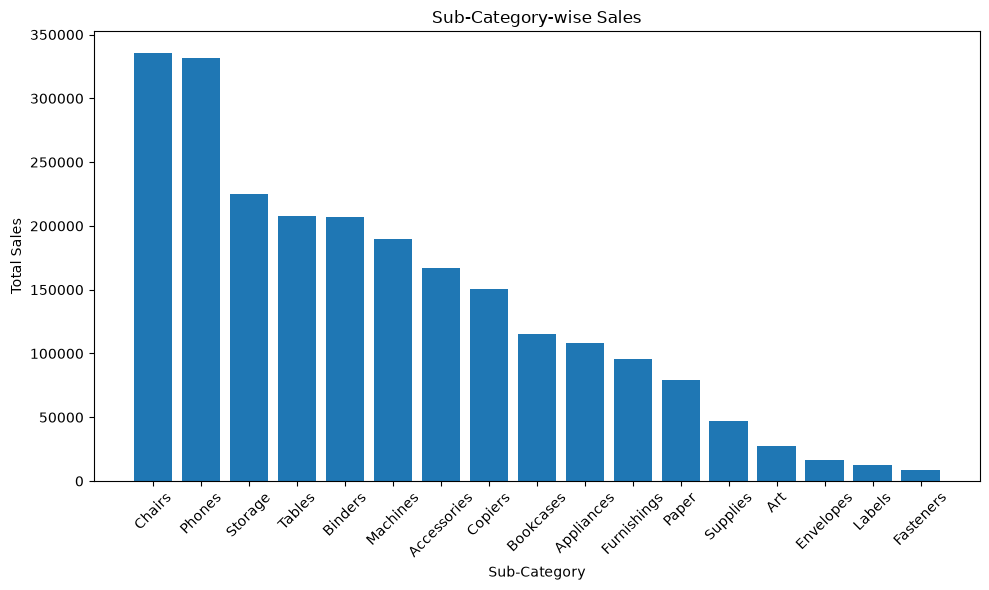

In [55]:
#Sales Chart
sales_chart = subcategory_analysis.sort_values(
    "Sales", ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    sales_chart["Sub_Category"],
    sales_chart["Sales"]
)

plt.title("Sub-Category-wise Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

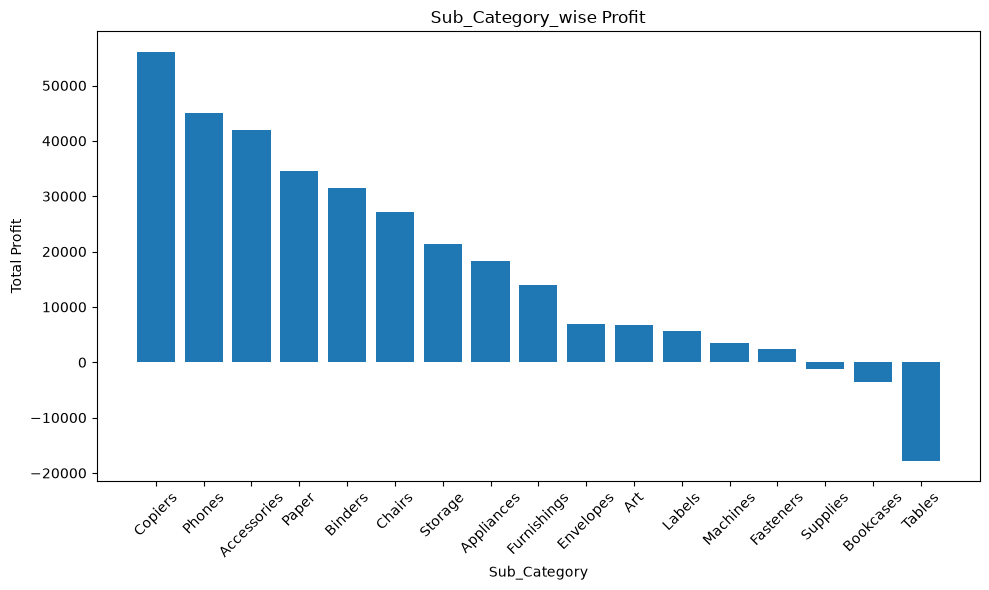

In [56]:
#Profit Chart for sub-categories
profit_chart = subcategory_analysis.sort_values(
    "Profit", ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    profit_chart["Sub_Category"],
    profit_chart["Profit"]
)

plt.title("Sub_Category_wise Profit")
plt.xlabel("Sub_Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
#Analyse Dsicount by sub-category
discount_subcategory = (
    df.groupby(["Sub_Category", "Discount_Band"], observed=False)
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

discount_subcategory["Profit_Margin"] = (
    discount_subcategory["Profit"] /
    discount_subcategory["Sales"] * 100
)

print(discount_subcategory)

   Sub_Category Discount_Band       Sales      Profit  Quantity  Profit_Margin
0   Accessories            0%  118370.310  35289.2539      1835      29.812589
1   Accessories         1-20%   49010.008   6647.3818      1141      13.563315
2   Accessories        21-40%       0.000      0.0000         0            NaN
3   Accessories          >40%       0.000      0.0000         0            NaN
4    Appliances            0%   78676.110  23358.9225      1038      29.689981
..          ...           ...         ...         ...       ...            ...
63     Supplies          >40%       0.000      0.0000         0            NaN
64       Tables            0%   71706.230  13334.9247       323      18.596605
65       Tables         1-20%  136313.952 -31088.1308       938     -22.806272
66       Tables        21-40%       0.000      0.0000         0            NaN
67       Tables          >40%       0.000      0.0000         0            NaN

[68 rows x 6 columns]


In [58]:
#negative profit combination
negative_combinations = (
    discount_subcategory
    .query("Profit < 0")
    .sort_values("Profit")
)

print(negative_combinations)

   Sub_Category Discount_Band        Sales      Profit  Quantity  \
65       Tables         1-20%  136313.9520 -31088.1308       938   
45     Machines         1-20%  118891.0310 -23675.8454       304   
17    Bookcases         1-20%   83425.2243  -9707.7853       667   
13      Binders         1-20%  122904.7810  -8994.9640      4715   
5    Appliances         1-20%   29537.0750  -5029.4381       712   
57      Storage         1-20%   66596.5840  -4288.2800      1131   
37  Furnishings         1-20%   31361.6460  -3860.1295      1467   
61     Supplies         1-20%   15114.3280  -2907.4937       247   

    Profit_Margin  
65     -22.806272  
45     -19.913904  
17     -11.636511  
13      -7.318645  
5      -17.027543  
57      -6.439189  
37     -12.308440  
61     -19.236672  


In [59]:
#worst combination
print(
    negative_combinations.head(10)
)

   Sub_Category Discount_Band        Sales      Profit  Quantity  \
65       Tables         1-20%  136313.9520 -31088.1308       938   
45     Machines         1-20%  118891.0310 -23675.8454       304   
17    Bookcases         1-20%   83425.2243  -9707.7853       667   
13      Binders         1-20%  122904.7810  -8994.9640      4715   
5    Appliances         1-20%   29537.0750  -5029.4381       712   
57      Storage         1-20%   66596.5840  -4288.2800      1131   
37  Furnishings         1-20%   31361.6460  -3860.1295      1467   
61     Supplies         1-20%   15114.3280  -2907.4937       247   

    Profit_Margin  
65     -22.806272  
45     -19.913904  
17     -11.636511  
13      -7.318645  
5      -17.027543  
57      -6.439189  
37     -12.308440  
61     -19.236672  


In [60]:
#High Discounts
high_discount = (
    df[df["Discount"] > 0.20]
    .groupby("Sub_Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

high_discount["Profit_Margin"] = (
    high_discount["Profit"] /
    high_discount["Sales"] * 100
)

print(
    high_discount.sort_values("Profit")
)

   Sub_Category       Sales      Profit  Quantity  Profit_Margin
2       Binders  36194.4530 -38562.2764      2468    -106.541951
12       Tables  90677.3700 -30789.7328       654     -33.955256
8      Machines  76839.1080 -29555.3521       180     -38.463945
3     Bookcases  28688.5868 -11295.3650       294     -39.372330
0    Appliances   3382.5340  -8629.6412       235    -255.123561
4        Chairs  70005.5020  -6737.1167       614      -9.623696
10       Phones  34337.3520  -6385.7854       414     -18.597198
6   Furnishings   7051.9800  -6134.0712       545     -86.983673
11      Storage    526.5820    -52.6582         2     -10.000000
7        Labels     82.9200    -31.3860         5     -37.850941
1           Art     39.9600    -23.9760         5     -60.000000
9         Paper     14.0000     -6.3000         4     -45.000000
5       Copiers  16919.8020   2182.9752        33      12.901896


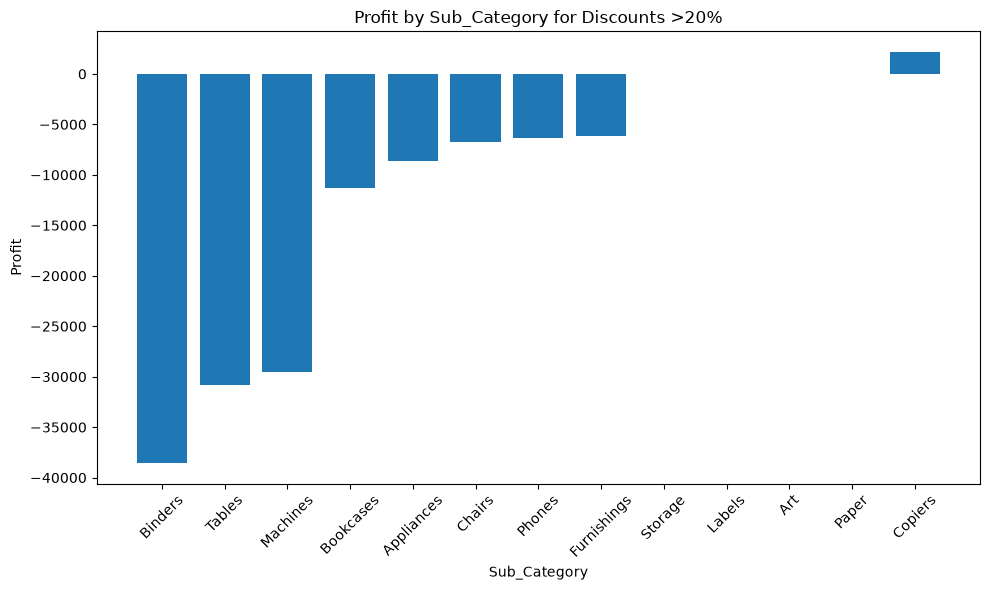

In [61]:
#Analyzing Chart

chart_data = high_discount.sort_values("Profit")

plt.figure(figsize=(10, 6))

plt.bar(
    chart_data["Sub_Category"],
    chart_data["Profit"]
)

plt.title("Profit by Sub_Category for Discounts >20%")
plt.xlabel("Sub_Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
#OverAll KPI Summary
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Unique Orders",
        "Unique Customers",
        "Profit Margin"
    ],
    "Value": [
        df["Sales"].sum(),
        df["Profit"].sum(),
        df["Quantity"].sum(),
        df["Order_ID"].nunique(),
        df["Customer_ID"].nunique(),
        (df["Profit"].sum() / df["Sales"].sum()) * 100
    ]
})

def format_kpis(row):
    metric = row['Metric']
    val = row['Value']
    
    if "Sales" in metric or "Profit" in metric and "Margin" not in metric:
        return f"${val:,.2f}"      # Currency: $1,234.56
    elif "Margin" in metric:
        return f"{val:.2f}%"       # Percentage: 15.34%
    else:
        return f"{int(val):,}"     # Whole Numbers with commas: 1,234


kpi_summary['Formatted Value'] = kpi_summary.apply(format_kpis, axis=1)


print(kpi_summary[['Metric', 'Formatted Value']])

             Metric Formatted Value
0       Total Sales   $2,326,534.35
1      Total Profit     $292,296.81
2    Total Quantity          38,654
3     Unique Orders           5,111
4  Unique Customers             804
5     Profit Margin          12.56%


In [63]:
#Category Summary
category_summary = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

category_summary["Profit_Margin"] = (
    category_summary["Profit"] /
    category_summary["Sales"] * 100
)

print(category_summary)

          Category        Sales       Profit  Quantity  Orders  Profit_Margin
0        Furniture  754747.7613   19729.9956      8369    1819       2.614118
1  Office Supplies  731893.3140  126023.4434     23268    3812      17.218827
2       Technology  839893.2790  146543.3756      7017    1560      17.447857


In [64]:
#Region Summary
region_summary = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

region_summary["Profit_Margin"] = (
    region_summary["Profit"] /
    region_summary["Sales"] * 100
)

print(region_summary)

    Region        Sales       Profit  Quantity  Orders  Profit_Margin
0  Central  503170.6728   39865.3070      8820    1179       7.922820
1     East  691828.1680   94883.2603     11159    1475      13.714859
2    South  391721.9050   46749.4303      6209     822      11.934342
3     West  739813.6085  110798.8170     12466    1635      14.976585


In [65]:
#sub-category summary
subcategory_summary = (
    df.groupby("Sub_Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

subcategory_summary["Profit_Margin"] = (
    subcategory_summary["Profit"] /
    subcategory_summary["Sales"] * 100
)

print(subcategory_summary)

   Sub_Category        Sales      Profit  Quantity  Orders  Profit_Margin
0   Accessories  167380.3180  41936.6357      2976     718      25.054700
1    Appliances  108213.1850  18329.4844      1750     459      16.938310
2           Art   27659.0140   6653.1962      3092     756      24.054351
3       Binders  207354.8810  31426.1003      6071    1339      15.155708
4     Bookcases  115361.2043  -3632.0736       878     228      -3.148436
5        Chairs  335768.2490  27223.5323      2431     591       8.107834
6       Copiers  150745.2900  56093.9365       242      70      37.211071
7     Envelopes   16528.3620   6988.0247       914     251      42.278991
8     Fasteners    8532.2400   2428.6358       980     226      28.464223
9   Furnishings   95598.1260  13891.7430      3799     919      14.531397
10       Labels   12695.0420   5572.7780      1410     348      43.897279
11     Machines  189925.0310   3461.9769       442     114       1.822812
12        Paper   79540.5380  34511.50

In [66]:
##Final Business Insights
print("Highest Sales Category:")
print(category_summary.loc[category_summary["Sales"].idxmax()])

print("\nHighest Profit Category:")
print(category_summary.loc[category_summary["Profit"].idxmax()])

print("\nHighest Sales Region:")
print(region_summary.loc[region_summary["Sales"].idxmax()])

print("\nHighest Profit Region:")
print(region_summary.loc[region_summary["Profit"].idxmax()])

print("\nHighest Sales Sub_Category:")
print(subcategory_summary.loc[subcategory_summary["Sales"].idxmax()])

print("\nHighest Profit Sub_Category:")
print(subcategory_summary.loc[subcategory_summary["Profit"].idxmax()])

print("\nLowest Profit Sub_Category:")
print(subcategory_summary.loc[subcategory_summary["Profit"].idxmin()])

Highest Sales Category:
Category          Technology
Sales             839893.279
Profit           146543.3756
Quantity                7017
Orders                  1560
Profit_Margin      17.447857
Name: 2, dtype: object

Highest Profit Category:
Category          Technology
Sales             839893.279
Profit           146543.3756
Quantity                7017
Orders                  1560
Profit_Margin      17.447857
Name: 2, dtype: object

Highest Sales Region:
Region                  West
Sales            739813.6085
Profit            110798.817
Quantity               12466
Orders                  1635
Profit_Margin      14.976585
Name: 3, dtype: object

Highest Profit Region:
Region                  West
Sales            739813.6085
Profit            110798.817
Quantity               12466
Orders                  1635
Profit_Margin      14.976585
Name: 3, dtype: object

Highest Sales Sub_Category:
Sub_Category         Chairs
Sales            335768.249
Profit           27223.5323
Qu

In [67]:
df[df['Profit'].isnull()][
    ['Order_ID', 'Order_Date', 'Product_ID', 'Product_Name',
     'Sales', 'Quantity', 'Discount', 'Profit']
]

,Order_ID,Order_Date,Product_ID,Product_Name,Sales,Quantity,Discount,Profit


In [68]:
# #check your final columns
# print(df.columns.tolist())
# df[df['Profit'].isnull()][
#     ['Sales', 'Quantity', 'Discount']
# ].describe()
print(df.shape)
print(df.head())
print(df.isnull().sum())

(10194, 24)
   Row_ID        Order_ID Order_Date  Ship_Date       Ship_Mode Customer_ID  \
0       1  US-2023-103800 2023-01-03 2023-01-07  Standard Class    DP-13000   
1       2  US-2023-112326 2023-01-04 2023-01-08  Standard Class    PO-19195   
2       3  US-2023-112326 2023-01-04 2023-01-08  Standard Class    PO-19195   
3       4  US-2023-112326 2023-01-04 2023-01-08  Standard Class    PO-19195   
4       5  US-2023-141817 2023-01-05 2023-01-12  Standard Class    MB-18085   

   Customer_Name      Segment        Country          City  ...  \
0  Darren Powers     Consumer  United States       Houston  ...   
1  Phillina Ober  Home Office  United States    Naperville  ...   
2  Phillina Ober  Home Office  United States    Naperville  ...   
3  Phillina Ober  Home Office  United States    Naperville  ...   
4     Mick Brown     Consumer  United States  Philadelphia  ...   

          Category Sub_Category  \
0  Office Supplies        Paper   
1  Office Supplies      Binders   
2  Of

In [69]:
df.describe()

,Row_ID,Order_Date,Ship_Date,Sales,Quantity,Discount,Profit,First_Order_Line,Returned_Flag
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417,0.501373,0.078478
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.000000,0.000000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800,0.000000,0.000000
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000,1.000000,0.000000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925,1.000000,0.000000
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,1.000000,1.000000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115,0.500023,0.268935


In [70]:
#Save Cleaned Dataset
df.to_csv(
    "Superstore_Cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully!")

PermissionError: [Errno 13] Permission denied: 'Superstore_Cleaned.csv'